# Chromatin States

In [1]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(targets)
  library(tidyplots)
  library(here)
})

tar_source(here("R"))

## Overlap Enrichment

In [2]:
combinations <- expand_grid(
  decile = 1:10,
  tp = paste0("Tp", 0:17)
)

overlap_enrichments_results <- pmap_dfr(combinations, function(decile, tp) {
  dec_str <- paste0("decile", str_pad(decile, width = 2, pad = "0"))
  read_tsv(
    str_glue("results/chromatin_states/overlap/{tp}/{dec_str}.txt"),
    show_col_types = FALSE
  ) %>%
    rename(
      state = "State (Emission order)",
      genome = "Genome %",
      genes = str_glue("{dec_str}_genes.bed"),
      tss2kb = str_glue("{dec_str}_tss2kb.bed"),
      exons = str_glue("{dec_str}_exons.bed")
    ) %>%
    mutate(decile = decile, tp = tp) %>%
    pivot_longer(
      c(genome, genes, tss2kb, exons),
      names_to = "region",
      values_to = "enrichment"
    )
})

glimpse(overlap_enrichments_results)

Rows: 8,640
Columns: 5
$ state      <chr> "1", "1", "1", "1", "2", "2", "2", "2", "3", "3", "3", "3",…
$ decile     <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ tp         <chr> "Tp0", "Tp0", "Tp0", "Tp0", "Tp0", "Tp0", "Tp0", "Tp0", "Tp…
$ region     <chr> "genome", "genes", "tss2kb", "exons", "genome", "genes", "t…
$ enrichment <dbl> 4.25319, 0.18064, 0.18024, 0.11959, 77.39879, 0.68021, 0.25…


In [3]:
overlap_enrichments_data <- overlap_enrichments_results %>%
  filter(state != "Base") %>%
  mutate(state_label = case_when(
    state == 1 ~ "PcRepr",
    state == 2 ~ "Quie",
    state == 3 ~ "ReprHet",
    state == 4 ~ "Tx",
    state == 5 ~ "WkGEnh",
    state == 6 ~ "WkEnh",
    state == 7 ~ "AEnh1",
    state == 8 ~ "AEnh2",
    state == 9 ~ "APr",
    state == 10 ~ "TSSUp",
    state == 11 ~ "TSSDn"
  )) %>%
  mutate(
    type = case_when(
      state %in% c(1, 2, 3) ~ "Repressive",
      state %in% c(4) ~ "Transcription",
      state %in% c(5, 6, 7, 8) ~ "Regulatory Element",
      state %in% c(9, 10, 11) ~ "Gene Feature"
    )
  ) %>%
  mutate(
    state = factor(state, level = 1:10),
    decile = factor(decile, level = rev(1:10)),
    tp = factor(tp),
    region = factor(region)
  ) %>%
  mutate(
    state_tp = interaction(state, tp)
  ) %>%
  mutate(
    log_enrichment = log2(enrichment)
  )

glimpse(overlap_enrichments_data)

mean_overlap_enrich <- overlap_enrichments_data %>%
  filter(!tp %in% c("Tp7", "Tp10")) %>%
  filter(region == "genes") %>%
  filter(decile == 1) %>%
  group_by(state, state_label, type) %>%
  summarise(enrichment = mean(enrichment))

Rows: 7,920
Columns: 9
$ state          <fct> 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5…
$ decile         <fct> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ tp             <fct> Tp0, Tp0, Tp0, Tp0, Tp0, Tp0, Tp0, Tp0, Tp0, Tp0, Tp0, …
$ region         <fct> genome, genes, tss2kb, exons, genome, genes, tss2kb, ex…
$ enrichment     <dbl> 4.25319, 0.18064, 0.18024, 0.11959, 77.39879, 0.68021, …
$ state_label    <chr> "PcRepr", "PcRepr", "PcRepr", "PcRepr", "Quie", "Quie",…
$ type           <chr> "Repressive", "Repressive", "Repressive", "Repressive",…
$ state_tp       <fct> 1.Tp0, 1.Tp0, 1.Tp0, 1.Tp0, 2.Tp0, 2.Tp0, 2.Tp0, 2.Tp0,…
$ log_enrichment <dbl> 2.0885453, -2.4688107, -2.4720089, -3.0638313, 6.274239…


`summarise()` has grouped output by 'state', 'state_label'. You can override
using the `.groups` argument.


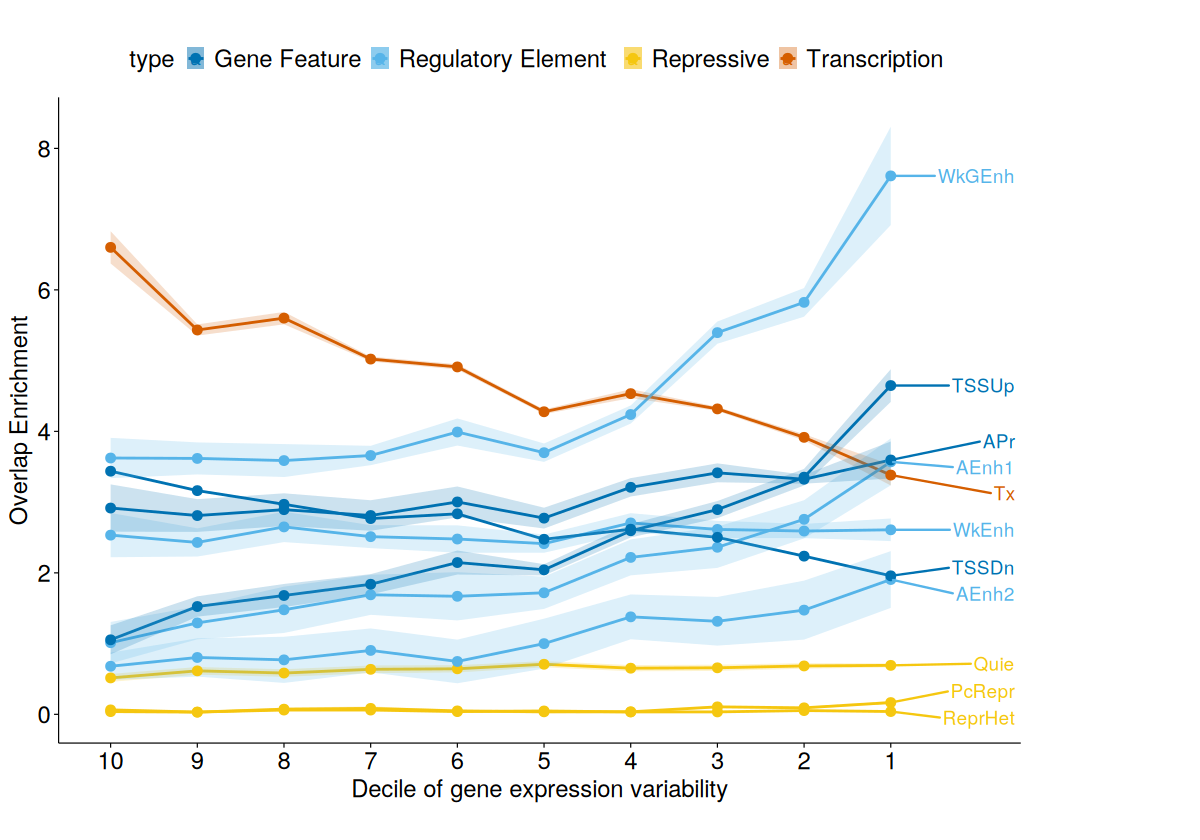

In [4]:
options(repr.plot.width = 10)

overlap_enrichments_data %>%
  filter(!tp %in% c("Tp7", "Tp10")) %>%
  filter(region == "genes") %>%
  tidyplot(
    x = decile,
    y = enrichment,
    color = type,
    group = state,
    dodge_width = 0
  ) %>%
  # add_mean_line(group = state, linewidth = 0.2) %>%
  # add_sd_errorbar() %>%
  add_mean_line(linewidth = 0.6, alpha = 1) %>%
  add_sd_ribbon(data = filter_rows(state == 1), alpha = 0.2) %>%
  add_sd_ribbon(data = filter_rows(state == 2), alpha = 0.2) %>%
  add_sd_ribbon(data = filter_rows(state == 3), alpha = 0.2) %>%
  add_sd_ribbon(data = filter_rows(state == 4), alpha = 0.2) %>%
  add_sd_ribbon(data = filter_rows(state == 5), alpha = 0.2) %>%
  add_sd_ribbon(data = filter_rows(state == 6), alpha = 0.2) %>%
  add_sd_ribbon(data = filter_rows(state == 7), alpha = 0.2) %>%
  add_sd_ribbon(data = filter_rows(state == 8), alpha = 0.2) %>%
  add_sd_ribbon(data = filter_rows(state == 9), alpha = 0.2) %>%
  add_sd_ribbon(data = filter_rows(state == 10), alpha = 0.2) %>%
  add_sd_ribbon(data = filter_rows(state == 11), alpha = 0.2) %>%
  add_mean_dot() %>%
  # add_data_labels_repel(
  #   label = state_label,
  #   data = filter_rows(decile == 1 & tp == "Tp8"),
  #   direction = "y",
  #   hjust = 0,
  #   fontsize = 12,
  #   label_position = "right"
  # ) %>%
  adjust_x_axis_title("Decile of gene expression variability") %>%
  adjust_y_axis_title("Overlap Enrichment") %>%
  add(
    ggrepel::geom_text_repel(
      data = mean_overlap_enrich,
      aes(x = 10, label = state_label), direction = "y",
      nudge_x = 1.5
    )
  ) %>%
  add(coord_cartesian(clip = "off")) %>%
  adjust_size(NA, NA) %>%
  adjust_font(fontsize = 14) %>%
  adjust_theme_details(
    legend.position = "top",
    legend.direction = "horizontal",
    plot.margin = margin(0.6, 3.6, 0.6, 0, "cm")
  )


## Coverage

In [5]:
coverages <- tar_read(coverages,
  store = here("results/R/chromatin_states")
) %>%
  mutate(state_label = case_when(
    state == 1 ~ "PcRepr",
    state == 2 ~ "Quie",
    state == 3 ~ "ReprHet",
    state == 4 ~ "Tx",
    state == 5 ~ "WkGEnh",
    state == 6 ~ "WkEnh",
    state == 7 ~ "AEnh1",
    state == 8 ~ "AEnh2",
    state == 9 ~ "APr",
    state == 10 ~ "TSSUp",
    state == 11 ~ "TSSDn"
  )) %>%
  mutate(
    type = case_when(
      state %in% c(1, 2, 3) ~ "Repressive",
      state %in% c(4) ~ "Transcription",
      state %in% c(5, 6, 7, 8) ~ "Regulatory Element",
      state %in% c(9, 10, 11) ~ "Gene Feature"
    )
  ) %>%
  mutate(
    tp = factor(tp, levels = paste0("Tp", 0:17)),
    state = factor(state, levels = 1:11),
    decile = factor(decile, levels = rev(1:10)),
    state_label = factor(state_label, levels = c(
      "PcRepr", "Quie", "ReprHet", "Tx", "WkGEnh", "WkEnh", "AEnh1", "AEnh2",
      "APr", "TSSUp", "TSSDn"
    ))
  ) %>%
  filter(!tp %in% c("Tp7", "Tp10")) %>%
  filter(!is.na(state))

summary(coverages, n = 20)

     state        coverage            decile          tp        state_label 
 2      :160   Min.   : 0.00044   10     :176   Tp0    : 110   Quie   :160  
 3      :160   1st Qu.: 0.55648   8      :176   Tp1    : 110   ReprHet:160  
 4      :160   Median : 1.88947   7      :176   Tp3    : 110   Tx     :160  
 5      :160   Mean   : 9.10125   5      :176   Tp4    : 110   WkGEnh :160  
 6      :160   3rd Qu.: 7.52629   4      :176   Tp5    : 110   WkEnh  :160  
 7      :160   Max.   :60.95961   3      :176   Tp6    : 110   AEnh1  :160  
 (Other):798                      (Other):702   (Other):1098   (Other):798  
     type          
 Length:1758       
 Class :character  
 Mode  :character  
                   
                   
                   
                   

### Coverages for each timepoint

✔ split_plot: split into 11 plots across 1 page



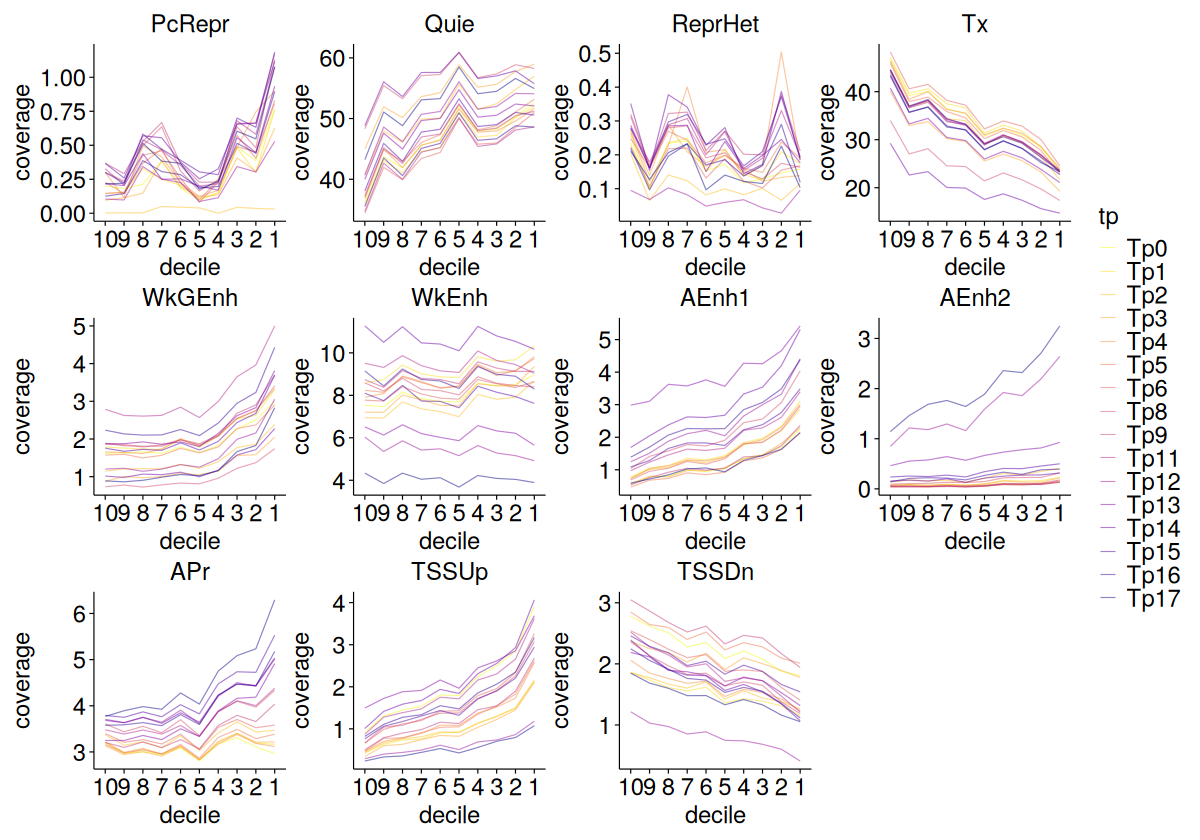

In [6]:
coverages %>%
  tidyplot(x = decile, y = coverage, color = tp) %>%
  add_line(alpha = 0.5) %>%
  adjust_colors(rev(colors_continuous_plasma)) %>%
  # add_mean_line() %>%
  # add_sd_ribbon() %>%
  adjust_size(NA, NA) %>%
  adjust_font(fontsize = 14) %>%
  split_plot(state_label)

### Coverages (timepoints averaged)

✔ save_plot: saved to /home/mriedl/Nextcloud/PhD/BioToP/Seminars/2025-10-30_DocSeminar/figures/chromstates.pdf



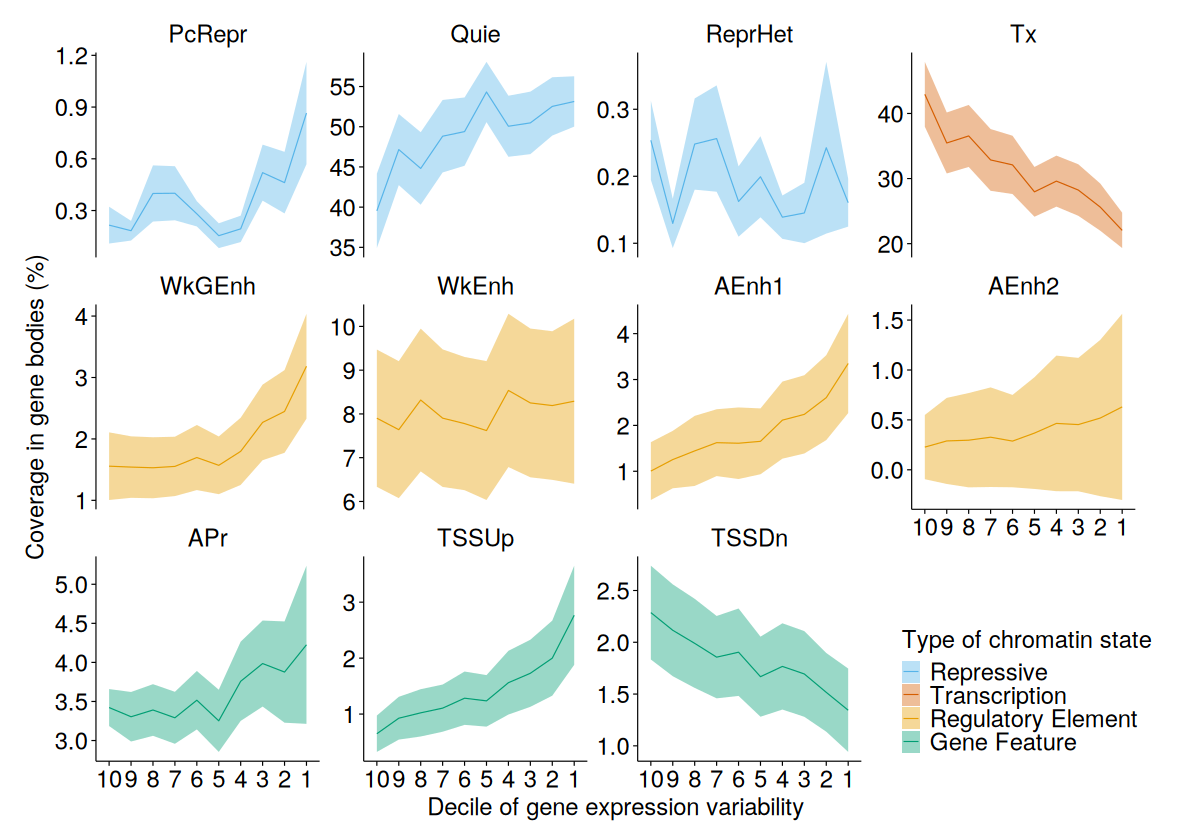

In [ ]:
coverages %>%
  mutate(
    type = factor(type, levels = c(
      "Repressive",
      "Transcription",
      "Regulatory Element",
      "Gene Feature"
    ))
  ) %>%
  tidyplot(x = decile, y = coverage, color = type, group = state) %>%
  add_mean_line() %>%
  add_sd_ribbon() %>%
  # adjust_colors(rev(colors_continuous_rocket)) %>%
  # add_mean_line() %>%
  # add_sd_ribbon() %>%
  adjust_x_axis_title("Decile of gene expression variability") %>%
  adjust_y_axis_title("Coverage in gene bodies (%)") %>%
  adjust_legend_title("Type of chromatin state") %>%
  adjust_colors(colors_discrete_friendly[c(2, 6, 5, 3)]) %>%
  adjust_size(220, 150) %>%
  adjust_font(fontsize = 14) %>%
  ggpubr::facet(facet.by = "state_label", scales = "free_y") %>%
  adjust_theme_details(
    legend.position = "inside",
    legend.position.inside = c(0.9, 0.1),
    plot.margin = margin(0.1, 1, 0.2, 0.2, "cm")
  )# %>%
  # save_plot(
  #   str_glue("/home/mriedl/Nextcloud/PhD/BioToP/Seminars/2025-10-30_DocSeminar/figures/chromstates.pdf"),
  #   width = 250, height = 180
  # )